<a href="https://colab.research.google.com/github/rachakondasaivarshini/GAN-PROGRAMS/blob/main/GAN_EXP_7_In_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

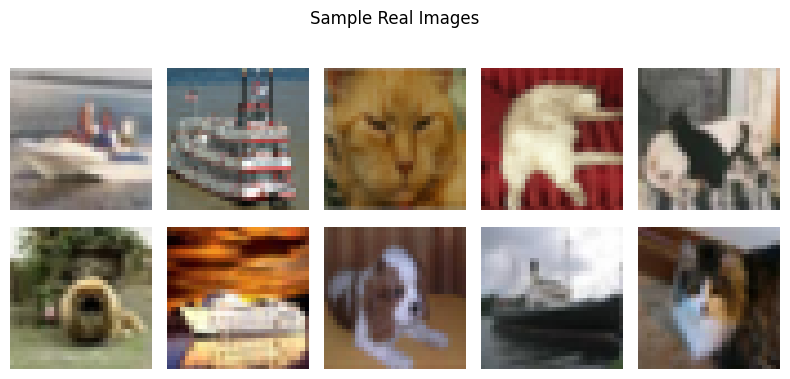


DCGAN training started...

Epoch 01/10 | Generator Loss: 0.6708 | Discriminator Loss: 1.2834


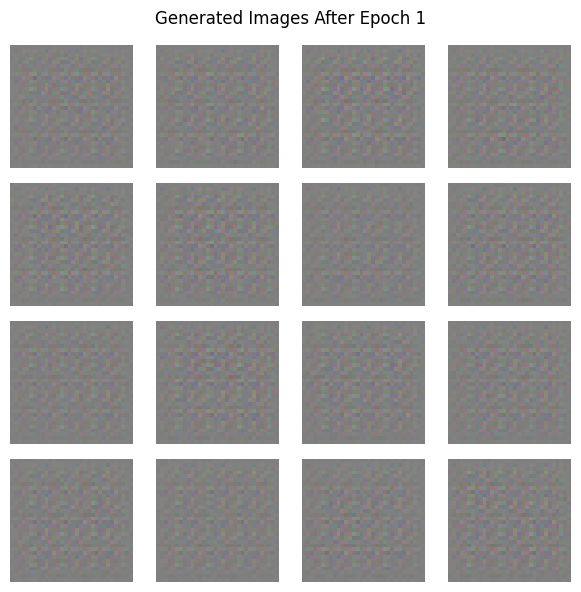

Epoch 02/10 | Generator Loss: 0.9399 | Discriminator Loss: 0.9110
Epoch 03/10 | Generator Loss: 1.5045 | Discriminator Loss: 0.5392
Epoch 04/10 | Generator Loss: 1.6224 | Discriminator Loss: 0.6064
Epoch 05/10 | Generator Loss: 1.5185 | Discriminator Loss: 0.6928


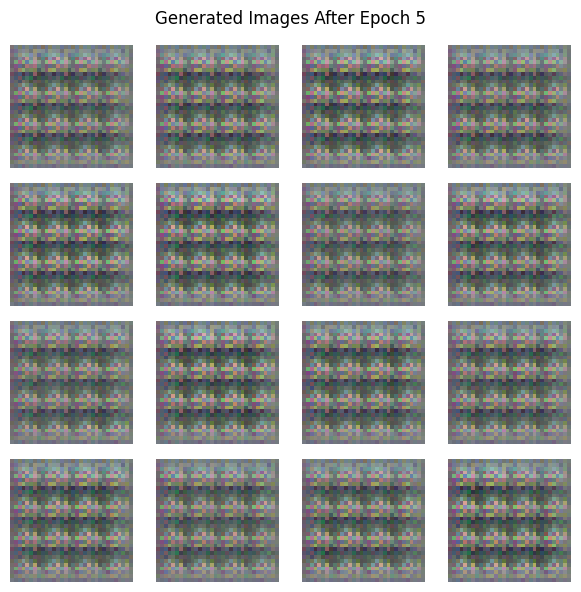

Epoch 06/10 | Generator Loss: 1.4891 | Discriminator Loss: 0.7178
Epoch 07/10 | Generator Loss: 1.4128 | Discriminator Loss: 0.7546
Epoch 08/10 | Generator Loss: 1.2523 | Discriminator Loss: 0.9210
Epoch 09/10 | Generator Loss: 1.2456 | Discriminator Loss: 0.9891
Epoch 10/10 | Generator Loss: 1.2146 | Discriminator Loss: 0.9778


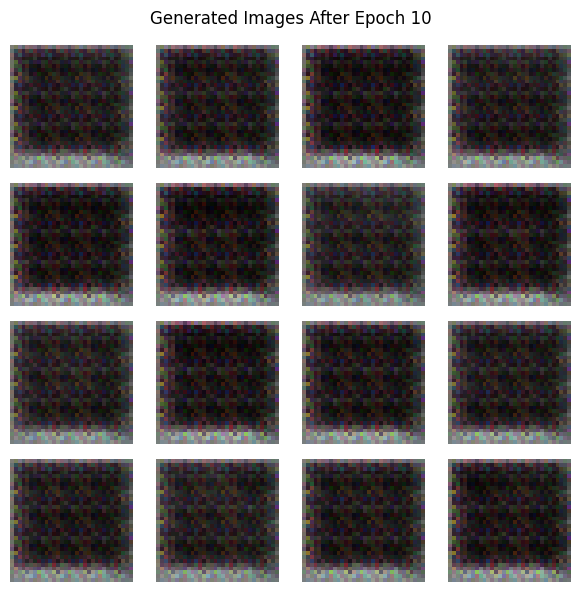

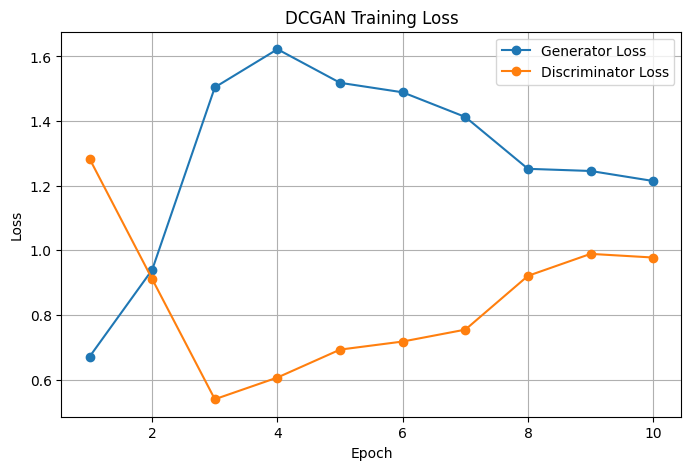

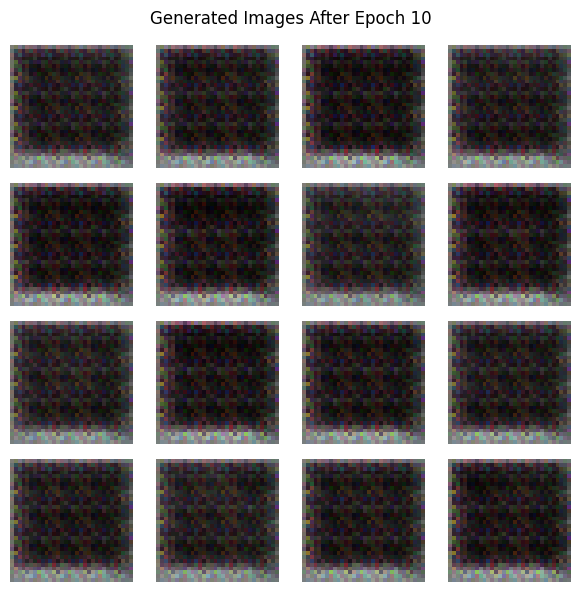

DCGAN training completed successfully.


In [2]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import time

tf.random.set_seed(42)
np.random.seed(42)

# Load CIFAR-10
(x_train, y_train), (_, _) = tf.keras.datasets.cifar10.load_data()
y_train = y_train.flatten()

# Select Cats, Dogs and Ships
selected_classes = [3, 5, 8]
images_per_class = 500

small_dataset = []

for class_number in selected_classes:
    class_images = x_train[y_train == class_number]
    small_dataset.append(class_images[:images_per_class])

x_train_small = np.concatenate(small_dataset, axis=0)
np.random.shuffle(x_train_small)

# Display real images
plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_small[i])
    plt.axis("off")
plt.suptitle("Sample Real Images")
plt.tight_layout()
plt.show()

# Normalize images
x_train_small = x_train_small.astype("float32")
x_train_small = (x_train_small - 127.5) / 127.5

BATCH_SIZE = 64
NOISE_DIM = 100
EPOCHS = 10

train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_train_small)
    .shuffle(len(x_train_small))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Generator
def build_generator():
    model = tf.keras.Sequential(name="Generator")

    model.add(layers.Input(shape=(NOISE_DIM,)))
    model.add(layers.Dense(4 * 4 * 128, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Reshape((4, 4, 128)))

    model.add(layers.Conv2DTranspose(
        128, kernel_size=4, strides=2,
        padding="same", use_bias=False
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(
        64, kernel_size=4, strides=2,
        padding="same", use_bias=False
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(
        3, kernel_size=4, strides=2,
        padding="same", activation="tanh"
    ))

    return model

generator = build_generator()

# Discriminator
def build_discriminator():
    model = tf.keras.Sequential(name="Discriminator")

    model.add(layers.Input(shape=(32, 32, 3)))

    model.add(layers.Conv2D(
        64, kernel_size=4, strides=2, padding="same"
    ))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(
        128, kernel_size=4, strides=2, padding="same"
    ))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

discriminator = build_discriminator()

# Loss functions
binary_cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

def generator_loss(fake_output):
    return binary_cross_entropy(
        tf.ones_like(fake_output), fake_output
    )

def discriminator_loss(real_output, fake_output):
    real_loss = binary_cross_entropy(
        tf.ones_like(real_output), real_output
    )
    fake_loss = binary_cross_entropy(
        tf.zeros_like(fake_output), fake_output
    )
    return real_loss + fake_loss

# Optimizers
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002, beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002, beta_1=0.5
)

# Training step
@tf.function
def train_step(real_images):

    current_batch_size = tf.shape(real_images)[0]

    noise = tf.random.normal(
        [current_batch_size, NOISE_DIM]
    )

    with tf.GradientTape() as generator_tape, \
         tf.GradientTape() as discriminator_tape:

        generated_images = generator(
            noise, training=True
        )

        real_output = discriminator(
            real_images, training=True
        )

        fake_output = discriminator(
            generated_images, training=True
        )

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(
            real_output, fake_output
        )

    generator_gradients = generator_tape.gradient(
        gen_loss, generator.trainable_variables
    )

    discriminator_gradients = discriminator_tape.gradient(
        disc_loss, discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(generator_gradients, generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(discriminator_gradients, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss

# Display generated images
fixed_noise = tf.random.normal([16, NOISE_DIM])

def display_generated_images(epoch):

    generated_images = generator(
        fixed_noise, training=False
    )

    generated_images = (generated_images + 1.0) / 2.0

    plt.figure(figsize=(6, 6))

    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(
            np.clip(generated_images[i].numpy(), 0, 1)
        )
        plt.axis("off")

    plt.suptitle(
        f"Generated Images After Epoch {epoch}"
    )
    plt.tight_layout()
    plt.show()

# Train DCGAN
generator_loss_history = []
discriminator_loss_history = []

print("\nDCGAN training started...\n")

for epoch in range(1, EPOCHS + 1):

    total_generator_loss = 0.0
    total_discriminator_loss = 0.0
    number_of_batches = 0

    for real_image_batch in train_dataset:

        gen_loss, disc_loss = train_step(
            real_image_batch
        )

        total_generator_loss += float(gen_loss)
        total_discriminator_loss += float(disc_loss)
        number_of_batches += 1

    average_generator_loss = (
        total_generator_loss / number_of_batches
    )

    average_discriminator_loss = (
        total_discriminator_loss / number_of_batches
    )

    generator_loss_history.append(
        average_generator_loss
    )

    discriminator_loss_history.append(
        average_discriminator_loss
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Generator Loss: {average_generator_loss:.4f} | "
        f"Discriminator Loss: {average_discriminator_loss:.4f}"
    )

    if epoch == 1 or epoch % 5 == 0:
        display_generated_images(epoch)

# Loss graph
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    generator_loss_history,
    label="Generator Loss",
    marker="o"
)

plt.plot(
    range(1, EPOCHS + 1),
    discriminator_loss_history,
    label="Discriminator Loss",
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Training Loss")
plt.legend()
plt.grid()
plt.show()

# Final result
display_generated_images(EPOCHS)

print("DCGAN training completed successfully.")